In [ ]:
# =========================
# 0) Setup e imports - Competencia Data Mining UBA 2025
# =========================
!pip -q install polars==1.7.1 lightgbm==4.5.0 optuna==3.6.1 matplotlib seaborn

import polars as pl
from pathlib import Path
import json, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import optuna

# Seeds oficiales de la competencia
SEEDS = [509963, 739373, 794341, 900623, 917827]
# Semillas adicionales (números primos grandes)
SEEDS_EXTRA = [1299827, 1500007, 1700021, 1900009, 2100013]
SEEDS_ALL = SEEDS + SEEDS_EXTRA  # 10 semillas totales

# Montar Google Drive
drive.mount('/content/drive', force_remount=True)

# Paths definitivos
CSV_PATH    = Path("/content/drive/MyDrive/DATA MINING - UBA/DM_EyF/competencia_01_crudo.csv")
SCHEMA_PATH = Path("/content/drive/MyDrive/DATA MINING - UBA/DM_EyF/schema.json")
BASE_DIR    = Path("/content/drive/MyDrive/DM_EyF_2025")
SUBMIT_PATH = BASE_DIR / "submit_202106_v10.csv"

# Configuración de la competencia
TRAIN_MESES = [202101, 202102, 202103, 202104]  # Meses de entrenamiento
APPLY_MES   = 202106                            # Mes de aplicación


Mounted at /content/drive


In [ ]:
# =========================
# 1) Lectura de DF con Schema
# =========================

# Cargar schema
with open(SCHEMA_PATH) as f:
    schema_dict = json.load(f)

# Convertir strings a dtypes de Polars
schema = {k: getattr(pl, v) for k, v in schema_dict.items()}

# Lectura estricta (sin inferir tipos)
df = pl.read_csv(CSV_PATH, schema_overrides=schema)
df = df.rechunk()  # Compactar memoria

In [ ]:
# =========================
# 2) Construcción de clase_ternaria (baseline del profesor)
# =========================

def agregar_clase_ternaria_optimizada(df: pl.DataFrame) -> pl.DataFrame:
    """
    Versión optimizada usando Polars - Baseline del profesor
    """
    return (
        df.lazy()
        .sort(["numero_de_cliente", "foto_mes"])
        .with_columns([
            pl.when(
                pl.col("foto_mes").shift(-1).over("numero_de_cliente").is_null() &
                (pl.col("foto_mes") != pl.col("foto_mes").max())
            ).then(pl.lit("BAJA+1"))
            .when(
                pl.col("foto_mes").shift(-2).over("numero_de_cliente").is_null() &
                (pl.col("foto_mes") <= pl.col("foto_mes").max() - 2)
            ).then(pl.lit("BAJA+2"))
            .otherwise(pl.lit("CONTINUA"))
            .alias("clase_ternaria")
        ])
        .collect()
    )

# Agregar la columna clase_ternaria
df = agregar_clase_ternaria_optimizada(df)

# Tabla de frecuencia de clase_ternaria por foto_mes
tabla_clases = (
    df.pivot(
        values="numero_de_cliente",
        index="foto_mes",
        on="clase_ternaria",
        aggregate_function="len"
    )
    .fill_null(0)
)

print(tabla_clases)


shape: (6, 4)
┌──────────┬──────────┬────────┬────────┐
│ foto_mes ┆ CONTINUA ┆ BAJA+2 ┆ BAJA+1 │
│ ---      ┆ ---      ┆ ---    ┆ ---    │
│ i64      ┆ u32      ┆ u32    ┆ u32    │
╞══════════╪══════════╪════════╪════════╡
│ 202101   ┆ 160087   ┆ 824    ┆ 616    │
│ 202102   ┆ 160298   ┆ 1027   ┆ 830    │
│ 202103   ┆ 161122   ┆ 953    ┆ 1034   │
│ 202104   ┆ 161333   ┆ 1131   ┆ 954    │
│ 202105   ┆ 162783   ┆ 0      ┆ 1134   │
│ 202106   ┆ 164313   ┆ 0      ┆ 0      │
└──────────┴──────────┴────────┴────────┘


In [ ]:
# =========================
# 3) Feature Engineering Histórico - Lags y DeltaLags (baseline del profesor)
# =========================

# Excluir IDs y metadata
EXCLUDE = {"numero_de_cliente", "foto_mes", "clase_ternaria"}

# Identificar columnas numéricas
num_cols = [c for c, dt in zip(df.columns, df.dtypes)
            if c not in EXCLUDE and dt.is_numeric()]

def add_lags_and_deltas(df: pl.DataFrame, cols: list[str]) -> pl.DataFrame:
    """
    Agregar lags y deltas de orden 1 y 2 - Baseline del profesor
    """
    out = df.sort(["numero_de_cliente", "foto_mes"]).lazy()

    # Lags 1 y 2
    out = out.with_columns([
        pl.col(c).shift(1).over("numero_de_cliente").alias(f"{c}_lag1") for c in cols
    ] + [
        pl.col(c).shift(2).over("numero_de_cliente").alias(f"{c}_lag2") for c in cols
    ])

    # Delta 1: x_t - x_{t-1} ; Delta 2: x_t - x_{t-2}
    out = out.with_columns([
        (pl.col(c) - pl.col(f"{c}_lag1")).alias(f"{c}_d1") for c in cols
    ] + [
        (pl.col(c) - pl.col(f"{c}_lag2")).alias(f"{c}_d2") for c in cols
    ])

    return out.collect()

# Aplicar lags y deltas
df = add_lags_and_deltas(df, num_cols)


In [ ]:
# =========================
# 4) Hiperparámetros optimizados (Trial 29 - hardcodeado)
# =========================

best_params = {
    'num_iterations': 861,
    'learning_rate': 0.03856122449159856,
    'feature_fraction': 0.9052831704690247,
    'num_leaves': 376,
    'min_data_in_leaf': 3,
    'bagging_fraction': 0.90418552810305
}

In [ ]:
# =========================
# 5) Entrenamiento final con todas las semillas (SIN undersampling)
# =========================

# Split temporal
df_train = df.filter(pl.col("foto_mes").is_in(TRAIN_MESES))
df_apply = df.filter(pl.col("foto_mes") == APPLY_MES)

# Target binaria para entrenamiento
df_train = df_train.with_columns(
    (pl.col("clase_ternaria").is_in(["BAJA+1","BAJA+2"]).cast(pl.Int8)).alias("clase_binaria"),
    (pl.col("clase_ternaria") == "BAJA+2").cast(pl.Int8).alias("es_baja2")
)

# Features: todas las numéricas + lags + deltas (INCLUYENDO numero_de_cliente)
FEATURES = [c for c, dt in zip(df_train.columns, df_train.dtypes)
            if c not in {"foto_mes","clase_ternaria","clase_binaria","es_baja2"}
            and dt.is_numeric()]

# Convertir a pandas para LightGBM (SIN undersampling)
X_train_full = df_train.select(FEATURES).to_pandas()
y_train_full = df_train["clase_binaria"].to_pandas().values
y_train_baja2_full = df_train["es_baja2"].to_pandas().values
X_apply = df_apply.select(FEATURES).to_pandas()
id_apply = df_apply["numero_de_cliente"].to_pandas().values

# Constantes de ganancia
ganancia_acierto = 780000
costo_estimulo = 20000

# Función de evaluación de ganancia
def lgb_gan_eval(y_pred, data):
    """Función de evaluación personalizada para LightGBM basada en ganancia."""
    weight = data.get_weight()
    ganancia = np.where(weight == 1.00002, ganancia_acierto, 0) - np.where(weight < 1.00002, costo_estimulo, 0)
    ganancia = ganancia[np.argsort(y_pred)[::-1]]
    ganancia = np.cumsum(ganancia)
    return 'gan_eval', np.max(ganancia), True


# Almacenar modelos y predicciones
models = []
predictions_per_seed = []

for seed_idx, seed in enumerate(SEEDS_ALL, 1):
    is_original = seed in SEEDS
    seed_type = "Original" if is_original else "Extra"

    print(f"\n🚀 Iniciando entrenamiento Semilla {seed_idx}/{len(SEEDS_ALL)}: {seed} ({seed_type})")

    # Configuración del modelo
    lgb_params_seed = {
        "objective": "binary",
        "metric": "auc",
        "verbose": -1,
        "max_bin": 31,
        "learning_rate": best_params["learning_rate"],
        "feature_fraction": best_params["feature_fraction"],
        "num_leaves": best_params["num_leaves"],
        "min_data_in_leaf": best_params["min_data_in_leaf"],
        "bagging_fraction": best_params["bagging_fraction"],
        "force_row_wise": True,
        "num_threads": -1,
        "seed": seed,
        "bagging_seed": seed,
        "feature_fraction_seed": seed
    }

    # Crear pesos y dataset (SIN undersampling)
    weights = np.where(y_train_full == 1, 1.00002, 1.0)
    d_train_weighted = lgb.Dataset(X_train_full, label=y_train_full, weight=weights)

    # Entrenar modelo
    model = lgb.train(
        lgb_params_seed,
        d_train_weighted,
        num_boost_round=best_params["num_iterations"],
        feval=lgb_gan_eval,
        callbacks=[lgb.log_evaluation(period=-1)]
    )

    # Predicciones
    pred = model.predict(X_apply)

    models.append(model)
    predictions_per_seed.append(pred)




🚀 Iniciando entrenamiento Semilla 1/10: 509963 (Original)

🚀 Iniciando entrenamiento Semilla 2/10: 739373 (Original)

🚀 Iniciando entrenamiento Semilla 3/10: 794341 (Original)

🚀 Iniciando entrenamiento Semilla 4/10: 900623 (Original)

🚀 Iniciando entrenamiento Semilla 5/10: 917827 (Original)

🚀 Iniciando entrenamiento Semilla 6/10: 1299827 (Extra)

🚀 Iniciando entrenamiento Semilla 7/10: 1500007 (Extra)

🚀 Iniciando entrenamiento Semilla 8/10: 1700021 (Extra)

🚀 Iniciando entrenamiento Semilla 9/10: 1900009 (Extra)

🚀 Iniciando entrenamiento Semilla 10/10: 2100013 (Extra)


In [ ]:
# =========================
# 6) Predicciones binarias finales y archivo submit
# =========================

# Convertir lista de arrays a matriz numpy
predictions_matrix = np.array(predictions_per_seed)

# Calcular promedio de las predicciones de todas las semillas (ensamble)
final_predictions = np.mean(predictions_matrix, axis=0)

# Ordenar clientes por probabilidad descendente
clientes_ordenados = np.argsort(final_predictions)[::-1]

# Número óptimo de clientes a contactar (calculado previamente)
n_clientes_objetivo = 10250

# Generar predicciones binarias basadas en el número óptimo
predicciones_binarias = np.zeros(len(final_predictions), dtype=int)
predicciones_binarias[clientes_ordenados[:n_clientes_objetivo]] = 1

# Crear DataFrame final con predicciones binarias
submit_df = pl.DataFrame({
    "numero_de_cliente": id_apply[clientes_ordenados],
    "Predicted": predicciones_binarias[clientes_ordenados]
})

# Guardar archivo de submit
submit_df.write_csv(SUBMIT_PATH)


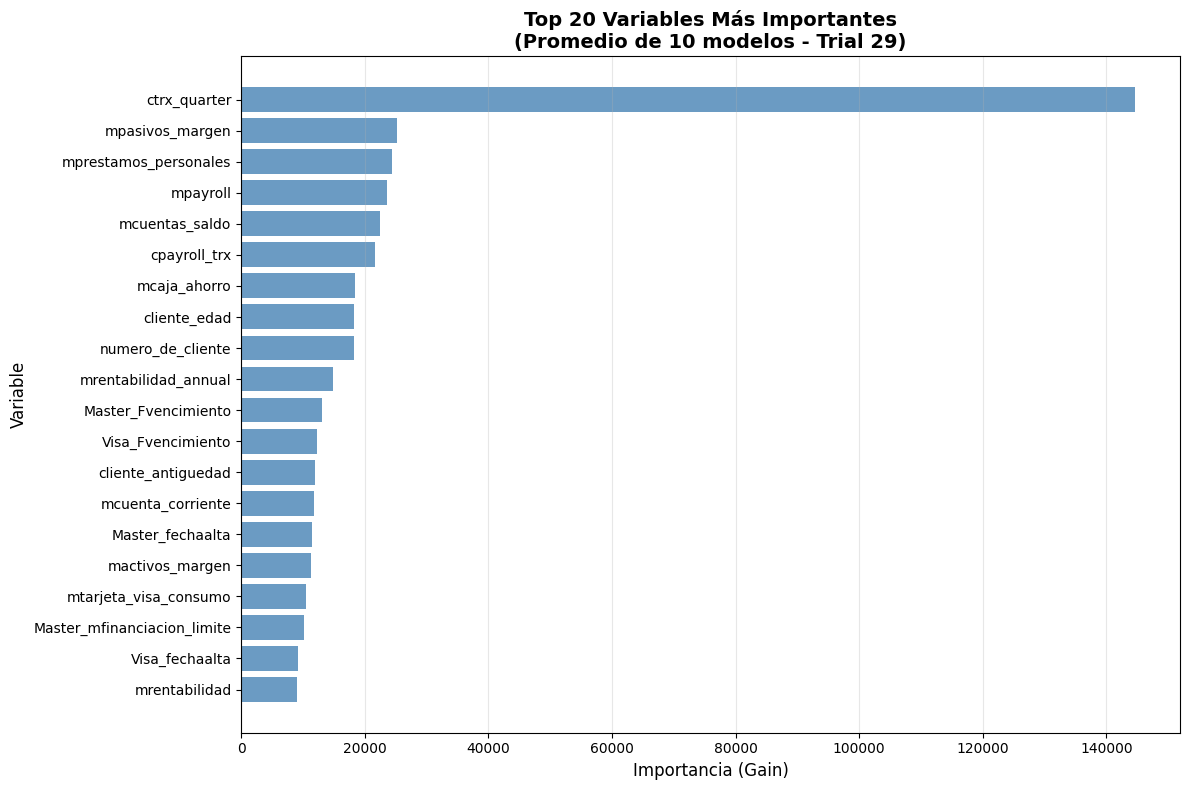

In [ ]:
# =========================
# 7) Feature Importance - Variables más importantes
# =========================

# Calcular feature importance promedio de todos los modelos
importances_list = []

for i, model in enumerate(models):
    importance = model.feature_importance(importance_type='gain')
    importances_list.append(importance)

# Promedio de importancias
avg_importance = np.mean(importances_list, axis=0)

# Crear DataFrame con feature names e importancias
importance_df = pl.DataFrame({
    'feature': FEATURES,
    'importance': avg_importance
}).sort('importance', descending=True)

# Top 30 features
top_30 = importance_df.head(30)

# Gráfico de las top 20
plt.figure(figsize=(12, 8))
top_20 = top_30.head(20).to_pandas()

plt.barh(range(len(top_20)), top_20['importance'], color='steelblue', alpha=0.8)
plt.yticks(range(len(top_20)), top_20['feature'])
plt.xlabel('Importancia (Gain)', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.title('Top 20 Variables Más Importantes\n(Promedio de 10 modelos - Trial 29)',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Para que la más importante esté arriba
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

